## Fred Garcia (fbg2107)
Homework Assignment 2: Profiling Small LLM Workloads

- let's start by getting the system info


In [139]:
import wandb
import os

# Completely reset wandb
# wandb.finish()

# # Clear any existing connection
# os.environ["WANDB_SILENT"] = "true"
# os.environ["WANDB_NETWORK_TIMEOUT"] = "60"

# # Try reinitializing
# try:
#     wandb.init(project="hpml-hw2-llm", reinit=True)
# except:
#     pass

socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x153e88b18370>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 153da0df55a0, raw_cell="import wandb
import os

# Completely reset wandb
#.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://tunnel%2Brusty/mnt/home/fgarcia/HPML_autumn25/pset2/hw2_fbg2107.ipynb#Y154sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x153e88b18370>> (for post_run_cell), with arguments args (<ExecutionResult object at 153da0df5390, execution_count=139 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 153da0df55a0, raw_cell="import wandb
import os

# Completely reset wandb
#.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://tunnel%2Brusty/mnt/home/fgarcia/HPML_autumn25/pset2/hw2_fbg2107.ipynb#Y154sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [ ]:
import torch
import psutil
import transformers
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer,
    DataCollatorWithPadding,
)
from datasets import load_dataset
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
# import wandb
import numpy as np
import random
import platform
import time

import cpuinfo


# gpu information
print(f"GPU : {torch.cuda.get_device_name(0)}")
gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU mem: {gpu_memory:.1f} GB")
# cpu information
print(f"CPU  model: {platform.processor()}")
print(
    f"CPU Cores: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical"
)
print(f"CPU info: {cpuinfo.get_cpu_info()['brand_raw']}")
# pytorch and transformers versions
print(f"PyTorch Version: {torch.__version__}")
print(f"Transformers Version: {transformers.__version__}")
# CUDA version (
print(f"CUDA version: {torch.version.cuda}")
# misc
print(f"Python Version: {platform.python_version()}")
print(f"system node RAM: {psutil.virtual_memory().total / (1024**3):.1f} GB")

socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x153e88b18370>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 153dc021ef50, raw_cell="import torch
import psutil
import transformers
fro.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://tunnel%2Brusty/mnt/home/fgarcia/HPML_autumn25/pset2/hw2_fbg2107.ipynb#W1sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

GPU : NVIDIA A100-SXM4-80GB
GPU mem: 85.2 GB
CPU  model: x86_64
CPU Cores: 64 physical, 64 logical


socket.send() raised exception.
socket.send() raised exception.


CPU info: Intel(R) Xeon(R) Platinum 8358 CPU @ 2.60GHz
PyTorch Version: 2.9.0+cu128
Transformers Version: 4.57.1
CUDA version: 12.8
Python Version: 3.10.4
system node RAM: 1007.6 GB
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x153e88b18370>> (for post_run_cell), with arguments args (<ExecutionResult object at 153dc021e830, execution_count=136 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 153dc021ef50, raw_cell="import torch
import psutil
import transformers
fro.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://tunnel%2Brusty/mnt/home/fgarcia/HPML_autumn25/pset2/hw2_fbg2107.ipynb#W1sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [2]:
# # get the wandb going
# wandb.init(project="hpml-hw2-llm")

# wandb.config.update(
#     {
#         "model_name": "distilbert-base-uncased",
#         "max_len": 256,
#         "batch_size": 32,
#         "lr": 1e-4,
#         "optimizer": "AdamW",
#         "num_workers": 2,
#         "epochs": 5,
#         "compile_mode": False,
#     }
# )

We can group runs by C, so it seems like C1 and C2 are asking for basically the same run but differnt profiling metrics?
We can just do separate runs with the same config but different profiling/logging code

In [3]:
# set seeds
seed = 144
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

load data and inspect

In [4]:
dataset = load_dataset("imdb")

In [5]:
print(f"train samples: {len(dataset['train'])}")
print(f"test samples: {len(dataset['test'])}")

# we can print the text in some training set
test_index = 144
print(f"sample review: {dataset['train'][144]['text'][:]}...")
print(f"label: {dataset['train'][144]['label']}")

train samples: 25000
test samples: 25000
sample review: I won't say this movie was bad, but it wasn't good either. I expected something good but I guess Hum Aapke Hain Kaun was much better than this. This was completely old fashioned. At every stage of this movie, I hoped for some twist and what do I get? The girl gets burned and wins her aunt's love. <br /><br />Despite of being engaged, they have to take permission for every little move they make. They are so darn shy even after so many meetings. I expected the aunt to be much more brutal than that. All she did was crib madly. <br /><br />Hey, we have kids too, but we don't watch them and have tears in our eyes always. This movie is a dream. Happy family, one cruel woman, good in-laws and a man who loves her to death. In HAHK Anupam Kher was the poor bride's father and now it's vice versa. And I somehow knew that Mohnish Behl would be in this movie. Anyway I believe I wasted my time. I give it a 2/10....
label: 0


ok it looks like we are looking at text and seeing if the movie is good or not (0 for bad, 1 for good)


the rest of the section for __Dataset and Model__




In [6]:
model_name = "distilbert-base-uncased"

# tokenaize
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
# move model to device with CUDA synchronization capability
device = torch.device("cuda")
model = model.to(device)

In [8]:
# we were told to use fixed sequence length so text will get truncated with this
MAX_LENGTH = 256
EPOCHS = 5

## C1

tokenzation (fixed length)

In [9]:
# we tocanize in this cell
# - sets truncation to true to cut off long reviews


def tokenize_function(examples):
    """tokenize with fixed max length , no padding (dynamic padding in collate_fn)"""
    return tokenizer(
        examples["text"],
        truncation=True,
        padding=False,  # dynamic padding handled in collate_fn
        max_length=MAX_LENGTH,  # fixed length for comparisons
        return_tensors=None,
    )


# we defined a function just for clarity, and apply his
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# remove text column and set format-- the words now will be turned into input_ids and attention_mask
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets.set_format("torch")

In [10]:
# use Hugging Face's built-in collator for dynamic padding
# pad to longest sequence in batch
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="longest",  # pad to longest sequence in batch
    return_tensors="pt",  # return PyTorch tensors
)

train_dataloader = DataLoader(
    tokenized_datasets["train"],
    batch_size=32,
    shuffle=True,
    collate_fn=data_collator,
    num_workers=2,  # can use >0 since DataCollator is picklable
)

test_dataloader = DataLoader(
    tokenized_datasets["test"],
    batch_size=32,
    shuffle=False,
    collate_fn=data_collator,
    num_workers=2,
)


print(f"train batches: {len(train_dataloader)}, test batches: {len(test_dataloader)}")
sample_batch = next(iter(train_dataloader))
print(
    f"sample batch - input_ids: {sample_batch['input_ids'].shape}, attention_mask: {sample_batch['attention_mask'].shape}"
)

train batches: 782, test batches: 782
sample batch - input_ids: torch.Size([32, 256]), attention_mask: torch.Size([32, 256])


In [11]:
#######
C1_wandb_config = {
    "model_name": "distilbert-base-uncased",
    "max_len": 256,
    "batch_size": 32,
    "lr": 1e-4,
    "optimizer": "AdamW",
    "num_workers": 2,
    "epochs": EPOCHS,
    "component": "C1_baseline",
}

# create meaningful run name and group
run_name = f"bs_{C1_wandb_config['batch_size']}_lr_{C1_wandb_config['lr']}_C1"
group_name = "C1_fine_tuning"

wandb.init(
    project="hpml-hw2-llm", name=run_name, group=group_name, config=C1_wandb_config
)
########

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

train_losses = []
train_accuracies = []
test_accuracies = []


def compute_accuracy(logits, labels):
    """compute accuracy given logits and true labels"""
    predictions = torch.argmax(logits, dim=-1)
    return (predictions == labels).float().mean()


for epoch in range(EPOCHS):
    print(f"epoch {epoch + 1}/{EPOCHS}")

    # training
    model.train()
    total_train_loss = 0
    total_train_acc = 0
    train_batches = 0

    for batch in tqdm(train_dataloader, desc="training"):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss
        logits = outputs.logits

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc = compute_accuracy(logits, batch["labels"])
        total_train_loss += loss.item()
        total_train_acc += acc.item()
        train_batches += 1

    avg_train_loss = total_train_loss / train_batches
    avg_train_acc = total_train_acc / train_batches

    # evaluation
    model.eval()
    total_test_acc = 0
    test_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc="Testing"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            acc = compute_accuracy(outputs.logits, batch["labels"])
            total_test_acc += acc.item()
            test_batches += 1

    avg_test_acc = total_test_acc / test_batches

    # store metrics needed
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)
    test_accuracies.append(avg_test_acc)

    # log to W&B
    wandb.log(
        {
            "train/loss": avg_train_loss,
            "train/accuracy": avg_train_acc,
            "test/accuracy": avg_test_acc,
            "epoch": epoch + 1,
        }
    )

    print(
        f"train Loss: {avg_train_loss:.4f}, train Acc: {avg_train_acc:.4f}, test Acc: {avg_test_acc:.4f}"
    )

wandb: Currently logged in as: fgarcia4 (fgarcia4-columbia-uni) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


epoch 1/5


Testing: 100%|██████████| 782/782 [00:43<00:00, 17.96it/s]


train Loss: 0.3084, train Acc: 0.8691, test Acc: 0.9009
epoch 2/5


Testing: 100%|██████████| 782/782 [00:43<00:00, 18.03it/s]


...

train Loss: 0.0866, train Acc: 0.9695, test Acc: 0.8816
epoch 4/5


Testing: 100%|██████████| 782/782 [00:43<00:00, 18.12it/s]


train Loss: 0.0546, train Acc: 0.9809, test Acc: 0.8794
epoch 5/5


Testing: 100%|██████████| 782/782 [00:43<00:00, 18.05it/s]

train Loss: 0.0383, train Acc: 0.9877, test Acc: 0.8698


### Figure F1

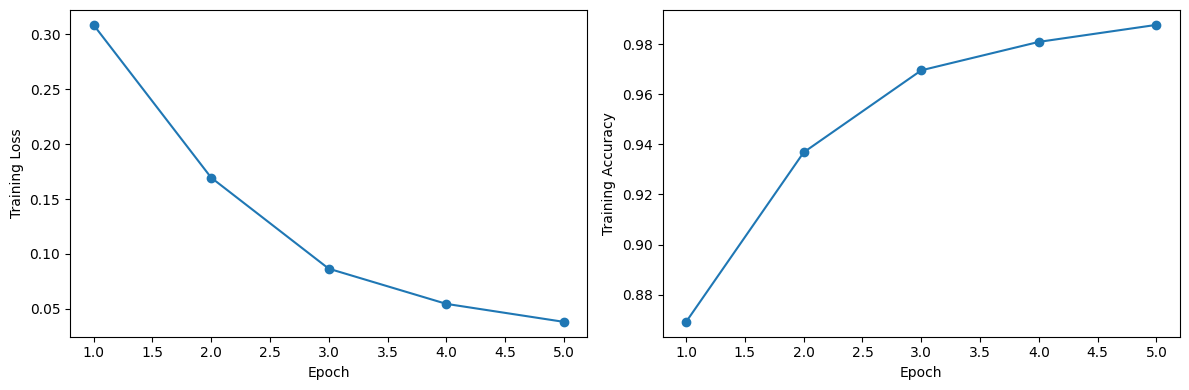

In [12]:
# This creates Figure F1
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: Training loss decreasing over epochs
ax[0].plot(range(1, EPOCHS + 1), train_losses, marker="o")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Training Loss")


# Right plot: Training and test accuracy increasing over epochs
ax[1].plot(range(1, EPOCHS + 1), train_accuracies, marker="o")
# ax[1].plot(range(1, 6), test_accuracies, marker="s", label="test accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Training Accuracy")
# ax[1].legend()


plt.tight_layout()
plt.savefig("./C1_F1.png", dpi=300, bbox_inches="tight")
plt.show()

### Table T1

In [13]:
table_t1 = pd.DataFrame(
    {
        "Epoch": range(1, EPOCHS + 1),
        "Train Loss": [f"{loss:.4f}" for loss in train_losses],
        "Train Accuracy": [f"{acc:.4f}" for acc in train_accuracies],
        "Test Accuracy": [f"{acc:.4f}" for acc in test_accuracies],
    }
)
table_t1
wandb.log({"C2_Table_T1": wandb.Table(dataframe=table_t1)})
wandb.finish()

epoch,▁▃▅▆█
test/accuracy,█▆▄▃▁
train/accuracy,▁▅▇██
train/loss,█▄▂▁▁
epoch,5
test/accuracy,0.86977
train/accuracy,0.98765
train/loss,0.03827


## C2: baseline timing


we don't need the test eval loop according to post #107

In [14]:
######
C2_wandb_config = {
    "model_name": "distilbert-base-uncased",
    "sequence_length": 256,
    "batch_size": 32,
    "learning_rate": 1e-4,
    "optimizer": "AdamW",
    "number_dataloader_workers": 2,
    "epochs": 5,
    "device": "cuda",
    "torch_compile_enabled": False,
}
group_name = "C2_baseline_timing"
run_name = f"bs_{C2_wandb_config['batch_size']}_lr_{C2_wandb_config['learning_rate']}_C2"  # same config as C1 for fair timing comparison
wandb.init(
    project="hpml-hw2-llm", name=run_name, group=group_name, config=C2_wandb_config
)
######


# measuring: (a) data-loading time, (b) training compute time, (c) total epoch time
epoch_times = []  # (c) total training epoch time
data_loading_times = []  # (a) data loading time per epoch
compute_times = []  # (b) compute time per epoch (forward + backward + optimizer)

for epoch in range(5):
    print(f"Epoch {epoch + 1}/5")

    # training phase - with all timing components
    model.train()
    total_train_loss = 0
    total_train_acc = 0
    train_batches = 0

    # timing variables for this epoch's TRAINING
    epoch_data_loading_time = 0  # (a) Data loading time
    epoch_compute_time = 0  # (b) Compute time

    # start epoch timer (c) Total epoch time
    epoch_start_time = time.time()

    for batch in tqdm(train_dataloader, desc=f"Timing Epoch {epoch+1}"):
        # data loading time
        data_load_start = time.time()

        batch = {k: v.to(device) for k, v in batch.items()}

        # CUDA synchronization for accurate timing
        torch.cuda.synchronize()

        data_load_end = time.time()
        epoch_data_loading_time += data_load_end - data_load_start

        # (b) COMPUTE TIME (forward + backward + optimizer)
        compute_start = time.time()

        # forward pass
        outputs = model(**batch)
        loss = outputs.loss
        logits = outputs.logits

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        torch.cuda.synchronize()  # CUDA sync for accurate timing

        compute_end = time.time()
        epoch_compute_time += compute_end - compute_start

        # metrics (not timed - part of compute overhead)
        acc = compute_accuracy(logits, batch["labels"])
        total_train_loss += loss.item()
        total_train_acc += acc.item()
        train_batches += 1

    # end epoch timer for training only
    epoch_end_time = time.time()
    epoch_total_time = epoch_end_time - epoch_start_time

    # timing consistency check (data + compute ~ total)
    timing_sum = epoch_data_loading_time + epoch_compute_time
    timing_diff = epoch_total_time - timing_sum
    print(
        f"   Timing check: Data+Compute={timing_sum:.2f}s, Total={epoch_total_time:.2f}s, Diff={timing_diff:.2f}s"
    )

    # store timing metrics
    epoch_times.append(epoch_total_time)
    data_loading_times.append(epoch_data_loading_time)
    compute_times.append(epoch_compute_time)

    # calculate training metrics
    avg_train_loss = total_train_loss / train_batches
    avg_train_acc = total_train_acc / train_batches

    # evaluation phase - NO TIMING FOR C2
    model.eval()
    total_test_acc = 0
    test_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc=f"Testing Epoch {epoch+1}"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            acc = compute_accuracy(outputs.logits, batch["labels"])
            total_test_acc += acc.item()
            test_batches += 1

    avg_test_acc = total_test_acc / test_batches

    # log to W&B - TRAINING TIMING ONLY
    wandb.log(
        {
            "train/loss": avg_train_loss,
            "train/accuracy": avg_train_acc,
            "test/accuracy": avg_test_acc,
            "time/data_loading": epoch_data_loading_time,  # (a)
            "time/compute": epoch_compute_time,  # (b)
            "time/epoch_total": epoch_total_time,  # (c)
            "epoch": epoch + 1,
        }
    )

    print(f"Epoch {epoch+1} Complete")
    print(f"   (a) Data Loading: {epoch_data_loading_time:.2f}s")
    print(f"   (b) Compute Time: {epoch_compute_time:.2f}s")
    print(f"   (c) Total Epoch:  {epoch_total_time:.2f}s")
    print(f"   Test Accuracy:    {avg_test_acc:.4f}")

Epoch 1/5


Timing Epoch 1: 100%|██████████| 782/782 [02:07<00:00,  6.11it/s]


   Timing check: Data+Compute=124.87s, Total=127.97s, Diff=3.10s


Testing Epoch 1: 100%|██████████| 782/782 [00:43<00:00, 18.06it/s]


Epoch 1 Complete
   (a) Data Loading: 0.15s
   (b) Compute Time: 124.72s
   (c) Total Epoch:  127.97s
   Test Accuracy:    0.8671
Epoch 2/5


...

Epoch 4 Complete
   (a) Data Loading: 0.15s
   (b) Compute Time: 124.62s
   (c) Total Epoch:  127.88s
   Test Accuracy:    0.8324
Epoch 5/5


Timing Epoch 5: 100%|██████████| 782/782 [02:07<00:00,  6.11it/s]


   Timing check: Data+Compute=124.83s, Total=128.01s, Diff=3.18s


Testing Epoch 5: 100%|██████████| 782/782 [00:43<00:00, 18.06it/s]

Epoch 5 Complete
   (a) Data Loading: 0.15s
   (b) Compute Time: 124.68s
   (c) Total Epoch:  128.01s
   Test Accuracy:    0.8490


### Table T2 

In [52]:
# Create Table T2: Per-epoch timing metrics
table_t2 = pd.DataFrame(
    {
        "Epoch": range(1, 6),
        "Data Loading Time (s)": [f"{t:.4f}" for t in data_loading_times],
        "Compute Time (s)": [f"{t:.4f}" for t in compute_times],
        "Total Epoch Time (s)": [f"{t:.4f}" for t in epoch_times],
        "Device (GPU)": [torch.cuda.get_device_name(0)] * 5,
    }
)
table_t2

# Save table
# table_t2.to_csv('C2_timing_metrics.csv', index=False)

,Epoch,Data Loading Time (s),Compute Time (s),Total Epoch Time (s),Device (GPU)
0,1,0.1407,124.6936,128.4380,NVIDIA A100-SXM4-80GB
1,2,0.1353,124.6723,128.1004,NVIDIA A100-SXM4-80GB
2,3,0.1416,124.6331,128.0129,NVIDIA A100-SXM4-80GB
3,4,0.1462,124.6081,128.0571,NVIDIA A100-SXM4-80GB
4,5,0.1149,124.6602,127.7348,NVIDIA A100-SXM4-80GB


In [16]:
wandb.log({"C2_Table_T2": wandb.Table(dataframe=table_t2)})
wandb.finish()

epoch,▁▃▅▆█
test/accuracy,█▅▅▁▄
time/compute,█▁█▂▅
time/data_loading,▇█▁▅█
time/epoch_total,▅█▆▁▇
train/accuracy,▁▃▂▄█
train/loss,█▅▆▅▁
epoch,5
test/accuracy,0.84898
time/compute,124.67739
time/data_loading,0.14829


### Figure F2

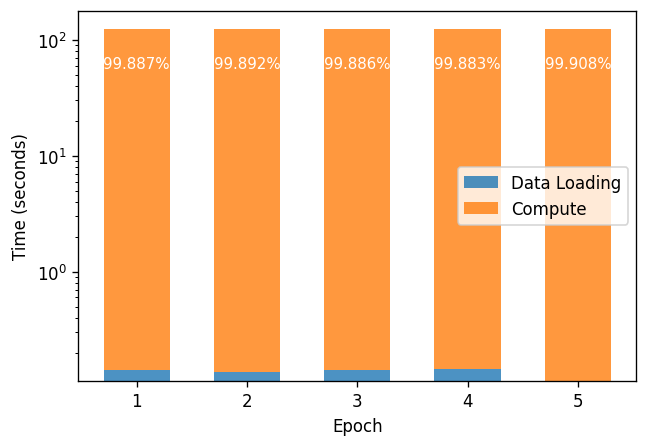

In [45]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)

# Create stacked bars for training timing only
epochs = range(1, 6)
bar_width = 0.6

bars1 = ax.bar(
    epochs,
    data_loading_times,
    bar_width,
    label="Data Loading",
    alpha=0.8,
)
bars2 = ax.bar(
    epochs,
    compute_times,
    bar_width,
    bottom=data_loading_times,
    label="Compute",
    alpha=0.8,
)

# Add labels and formatting
ax.set(xlabel="Epoch", ylabel="Time (seconds)", yscale="log")

ax.set_xticks(epochs)
ax.legend()


# add compute percentage labels on bars
for i, (data_time, compute_time) in enumerate(zip(data_loading_times, compute_times)):
    total_time = data_time + compute_time
    compute_pct = (compute_time / total_time) * 100
    ax.text(
        i + 1,
        data_time + compute_time / 2,
        f"{compute_pct:.3f}%",
        ha="center",
        va="center",
        fontsize=9,
        color="white",
    )


plt.savefig("C2_F2.png", dpi=300, bbox_inches="tight")
plt.show()

## C3: DataLoader Performance Comparison

In [ ]:
# Test different num_workers values
num_workers_list = [0, 2, 4, 8]
results = []

for num_workers in num_workers_list:
    print(f"testing num_workers = {num_workers}")
    # W&B Configuration for this run
    wandb_config = {
        "model_name": "distilbert-base-uncased",
        "sequence_length": 256,
        "batch_size": 32,
        "learning_rate": 1e-4,
        "optimizer": "AdamW",
        "number_dataloader_workers": num_workers,  # Varied parameter
        "epochs": 5,
        "device": "cuda",
        "torch_compile_enabled": False,
        "component": "C3_dataloader",
    }

    run_name = f"bs_32_lr_1e-4_workers_{num_workers}"
    group_name = "C3_num_workers_compare"

    wandb.init(
        project="hpml-hw2-llm", name=run_name, group=group_name, config=wandb_config
    )

    # recreate DataLoaders with current num_workers
    train_dataloader = DataLoader(
        tokenized_datasets["train"],
        batch_size=32,
        shuffle=True,
        collate_fn=data_collator,
        num_workers=num_workers,  # This is what we're testing
    )

    # reinitialize model and optimizer for fair comparison
    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=2
    )
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

    # training metrics storage for this run - ADD TRAIN LOSSES
    epoch_times = []
    data_loading_times = []
    compute_times = []
    train_accuracies = []
    train_losses = []
    test_accuracies = []

    # training loop with timing (similar to C2)
    for epoch in range(5):
        print(f"Epoch {epoch + 1}/5 - workers={num_workers}")

        # Training phase with timing
        model.train()
        epoch_data_loading_time = 0
        epoch_compute_time = 0
        total_train_acc = 0
        total_train_loss = 0
        train_batches = 0

        epoch_start_time = time.time()

        for batch in tqdm(train_dataloader, desc=f"workers={num_workers}"):
            # data loading time
            data_load_start = time.time()
            batch = {k: v.to(device) for k, v in batch.items()}
            torch.cuda.synchronize()
            data_load_end = time.time()
            epoch_data_loading_time += data_load_end - data_load_start

            # compute time
            compute_start = time.time()
            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            torch.cuda.synchronize()
            compute_end = time.time()
            epoch_compute_time += compute_end - compute_start

            # metrics
            acc = compute_accuracy(logits, batch["labels"])
            total_train_acc += acc.item()
            total_train_loss += loss.item()  # NEW: Accumulate loss
            train_batches += 1

        epoch_end_time = time.time()
        epoch_total_time = epoch_end_time - epoch_start_time

        # Calculate average training loss for this epoch
        avg_train_loss = total_train_loss / train_batches
        avg_train_acc = total_train_acc / train_batches

        # store metrics
        epoch_times.append(epoch_total_time)
        data_loading_times.append(epoch_data_loading_time)
        compute_times.append(epoch_compute_time)
        train_accuracies.append(avg_train_acc)
        train_losses.append(avg_train_loss)

        # quick test evaluation (no timing)
        model.eval()
        total_test_acc = 0
        test_batches = 0
        with torch.no_grad():
            for batch in test_dataloader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                acc = compute_accuracy(outputs.logits, batch["labels"])
                total_test_acc += acc.item()
                test_batches += 1

        test_accuracies.append(total_test_acc / test_batches)

        # Log to W&B - ADD TRAINING LOSS
        wandb.log(
            {
                "train/loss": avg_train_loss,
                "train/accuracy": train_accuracies[-1],
                "test/accuracy": test_accuracies[-1],
                "time/data_loading": epoch_data_loading_time,
                "time/compute": epoch_compute_time,
                "time/epoch_total": epoch_total_time,
                "epoch": epoch + 1,
            }
        )

        print(
            f"   Time: Data={epoch_data_loading_time:.2f}s, Compute={epoch_compute_time:.2f}s, Total={epoch_total_time:.2f}s"
        )
        print(
            f"   Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracies[-1]:.4f}, Test Acc: {test_accuracies[-1]:.4f}"  # Updated to show loss
        )

    avg_epoch_time = np.mean(epoch_times)
    avg_data_loading_time = np.mean(data_loading_times)
    avg_compute_time = np.mean(compute_times)
    final_train_loss = train_losses[-1]
    final_train_acc = train_accuracies[-1]
    final_test_acc = test_accuracies[-1]

    results.append(
        {
            "num_workers": num_workers,
            "avg_epoch_time": avg_epoch_time,
            "avg_data_loading_time": avg_data_loading_time,
            "avg_compute_time": avg_compute_time,
            "final_train_loss": final_train_loss,  # NEW
            "final_train_accuracy": final_train_acc,
            "final_test_accuracy": final_test_acc,
        }
    )

    print(f"num_workers={num_workers} Summary:")
    print(f"avg Epoch Time: {avg_epoch_time:.2f}s")
    print(f"final Train Loss: {final_train_loss:.4f}")  # NEW
    print(
        f"avg Data Loading: {avg_data_loading_time:.2f}s ({avg_data_loading_time/avg_epoch_time*100:.1f}%)"
    )
    print(f"final Test Accuracy: {final_test_acc:.4f}")

    wandb.finish()

testing num_workers = 0


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5 - workers=0


workers=0: 100%|██████████| 782/782 [02:12<00:00,  5.92it/s]


   Time: Data=0.14s, Compute=123.62s, Total=132.01s
   Loss: 0.3084, Train Acc: 0.8686, Test Acc: 0.9005
Epoch 2/5 - workers=0


...

workers=8: 100%|██████████| 782/782 [02:08<00:00,  6.11it/s]


   Time: Data=0.15s, Compute=124.61s, Total=128.06s
   Loss: 0.0567, Train Acc: 0.9809, Test Acc: 0.8523
Epoch 5/5 - workers=8


workers=8: 100%|██████████| 782/782 [02:07<00:00,  6.12it/s]


   Time: Data=0.11s, Compute=124.66s, Total=127.73s
   Loss: 0.0395, Train Acc: 0.9867, Test Acc: 0.8651
num_workers=8 Summary:
avg Epoch Time: 128.07s
final Train Loss: 0.0395
avg Data Loading: 0.14s (0.1%)
final Test Accuracy: 0.8651


epoch,▁▃▅▆█
test/accuracy,██▁▂▄
time/compute,█▆▃▁▅
time/data_loading,▇▆▇█▁
time/epoch_total,█▅▄▄▁
train/accuracy,▁▅▇██
train/loss,█▄▂▁▁
epoch,5
test/accuracy,0.86513
time/compute,124.66017
time/data_loading,0.11492


In [ ]:
table_t3_data = []
for result in results:
    row = {
        "Num Workers": result["num_workers"],
        "Avg Epoch Time (s)": f"{result['avg_epoch_time']:.2f}",
        "Avg Data Loading Time (s)": f"{result['avg_data_loading_time']:.2f}",
        "Avg Compute Time (s)": f"{result['avg_compute_time']:.2f}",
        "Final Train Loss": f"{result['final_train_loss']:.4f}",
        "Final Train Accuracy": f"{result['final_train_accuracy']:.4f}",
        "Final Test Accuracy": f"{result['final_test_accuracy']:.4f}",
        "Batch Size": 32,
    }
    table_t3_data.append(row)
    print(
        f"{result['num_workers']:<12} {result['avg_epoch_time']:<18.2f} {result['avg_data_loading_time']:<25.2f} {result['avg_compute_time']:<20.2f} {result['final_train_loss']:<16.4f} {result['final_train_accuracy']:<16.4f} {result['final_test_accuracy']:<15.4f}"
    )

table_t3 = pd.DataFrame(table_t3_data)

0            131.62             0.11                      123.66               0.0427           0.9860           0.8683         
2            127.63             0.12                      124.65               0.0397           0.9864           0.8685         
4            127.95             0.13                      124.71               0.0391           0.9877           0.8752         
8            128.07             0.14                      124.65               0.0395           0.9867           0.8651         


### Table T3

In [47]:
# display only num_workers and avg epoch time and avg data loading time and batch size
table_t3[
    ["Num Workers", "Avg Epoch Time (s)", "Avg Data Loading Time (s)", "Batch Size"]
]

,Num Workers,Avg Epoch Time (s),Avg Data Loading Time (s),Batch Size
0,0,131.62,0.11,32
1,2,127.63,0.12,32
2,4,127.95,0.13,32
3,8,128.07,0.14,32


### Figure F3
line plot of avg epoch time vs num workers

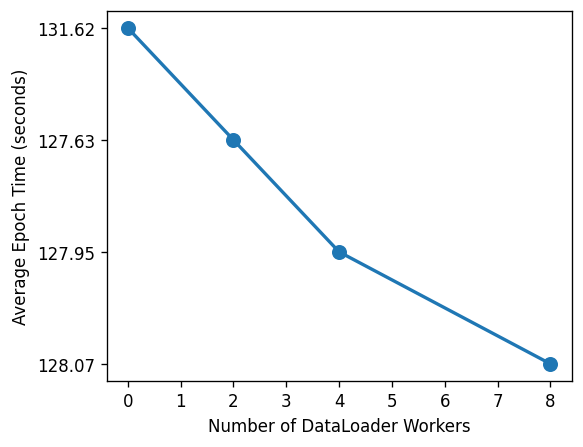

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4), dpi=120)
ax.plot(
    np.array(table_t3["Num Workers"]),
    np.array(table_t3["Avg Epoch Time (s)"]),
    marker="o",
    linewidth=2,
    markersize=8,
)

# reverse y axis
ax.invert_yaxis()
ax.set(xlabel="Number of DataLoader Workers", ylabel="Average Epoch Time (seconds)")
plt.savefig("C3_num_workers_performance.png", dpi=300, bbox_inches="tight")
plt.show()

#### One sentence conclusion about the results

There is a linear decrease in average epoch time as the number of DataLoader workers increases from 0 - 4, but going to 8 diminishes returns due to overhead from managing too many workers. The best is thus 4 workers for this setup.


## C4: PyTorch Profiler 



In [ ]:
import torch.profiler as profiler
from torch.profiler import profile, record_function, ProfilerActivity

PROFILER_BATCHES = 782  # Representative slice
SKIP_BATCHES = 1  # Skip first batch
WARMUP_BATCHES = 9  # Warmup batches
NUM_TOP_OPS = 10  # Number of top operations to display

In [ ]:
def run_profiler(num_workers, device="cuda"):
    """
    Profile one full epoch of DistilBERT training for C4.
    Logs per-phase percentages (for Table T4) and produces Figure F4 bar charts.
    """

    # ---- W&B setup ----
    wandb_config = {
        "model_name": "distilbert-base-uncased",
        "max_len": 256,
        "batch_size": 32,
        "lr": 1e-4,
        "optimizer": "AdamW",
        "num_workers": num_workers,
        "epochs": 1,
        "device": device,
        "component": "C4_profiler",
    }

    wandb.init(
        project="hpml-hw2-llm",
        name=f"C4_profiler_nw_{num_workers}",
        group="C4_profiler_nw_compare",
        config=wandb_config,
        reinit=True,
    )

    # ---- dataLoader & model ----
    train_loader = DataLoader(
        tokenized_datasets["train"],
        batch_size=32,
        shuffle=True,
        num_workers=num_workers,
        collate_fn=data_collator,
    )

    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased"
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    criterion = torch.nn.CrossEntropyLoss()
    model.train()

    # ---- profiler ----
    trace_dir = f"./profiler_nw{num_workers}"
    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        record_shapes=False,
        profile_memory=False,
        on_trace_ready=torch.profiler.tensorboard_trace_handler(trace_dir),
    ) as prof:

        epoch_start = time.time()

        for batch in tqdm(
            train_loader, desc=f"Profiling epoch (num_workers={num_workers})"
        ):
            inputs = {k: v.to(device) for k, v in batch.items()}
            labels = inputs.pop("labels")

            with record_function("forward"):
                outputs = model(**inputs)
                loss = criterion(outputs.logits, labels)

            with record_function("backward"):
                optimizer.zero_grad()
                loss.backward()

            with record_function("optimizer_step"):
                optimizer.step()

            prof.step()

        torch.cuda.synchronize()
        epoch_time = time.time() - epoch_start

    # ---- summary breakdown ----
    key_avg = prof.key_averages()
    total_cpu_time = sum(evt.self_cpu_time_total for evt in key_avg)
    get_pct = (
        lambda substr: sum(
            evt.self_cpu_time_total for evt in key_avg if substr in evt.key
        )
        / total_cpu_time
        * 100
    )

    breakdown = {
        "Setting": f"nw={num_workers}",
        "Data (%)": get_pct("DataLoader"),
        "Forward (%)": get_pct("forward"),
        "Backward (%)": get_pct("backward"),
        "Optimizer (%)": get_pct("optimizer"),
        "Epoch Time (s)": epoch_time,
    }

    wandb.log(
        {
            "epoch_time_s": epoch_time,
            "data_percent": breakdown["Data (%)"],
            "forward_percent": breakdown["Forward (%)"],
            "backward_percent": breakdown["Backward (%)"],
            "optimizer_percent": breakdown["Optimizer (%)"],
        }
    )

    # # ---- breakdown bar chart ----
    # fig, ax = plt.subplots(figsize=(5, 4))
    # bars = ["Data", "Forward", "Backward", "Optimizer"]
    # vals = [breakdown[f"{b} (%)"] for b in bars]
    # ax.bar(bars, vals, color=["skyblue", "orange", "lightgreen", "salmon"])
    # ax.set_ylabel("Percent of Total CPU Time")
    # ax.set_title(f"Breakdown (num_workers={num_workers})")
    # plt.tight_layout()
    # wandb.log({"breakdown_bar": wandb.Image(fig)})
    # plt.close(fig)

    wandb.finish()

    print(f"\nTrace saved to: {trace_dir}")
    print(pd.DataFrame([breakdown]))
    return breakdown, prof

In [87]:
res1, prof1 = run_profiler(1)
res4, prof4 = run_profiler(4)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Profiling epoch (num_workers=1): 100%|██████████| 782/782 [02:07<00:00,  6.16it/s]


backward_percent,▁
data_percent,▁
epoch_time_s,▁
forward_percent,▁
optimizer_percent,▁
backward_percent,6.57838
data_percent,1.74071
epoch_time_s,127.02025
forward_percent,1.25839
optimizer_percent,0.02522



Trace saved to: ./profiler_nw1
  Setting  Data (%)  Forward (%)  Backward (%)  Optimizer (%)  Epoch Time (s)
0    nw=1  1.740713     1.258395      6.578379       0.025221      127.020251


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Profiling epoch (num_workers=4): 100%|██████████| 782/782 [02:09<00:00,  6.06it/s]


backward_percent,▁
data_percent,▁
epoch_time_s,▁
forward_percent,▁
optimizer_percent,▁
backward_percent,6.60568
data_percent,2.15384
epoch_time_s,129.02185
forward_percent,1.2805
optimizer_percent,0.02662



Trace saved to: ./profiler_nw4
  Setting  Data (%)  Forward (%)  Backward (%)  Optimizer (%)  Epoch Time (s)
0    nw=4  2.153838     1.280505       6.60568       0.026619      129.021852


### Table T4: 

In [88]:
t4 = pd.DataFrame([res1, res4])
display(t4)

,Setting,Data (%),Forward (%),Backward (%),Optimizer (%),Epoch Time (s)
0,nw=1,1.740713,1.258395,6.578379,0.025221,127.020251
1,nw=4,2.153838,1.280505,6.605680,0.026619,129.021852


### Figure  F4

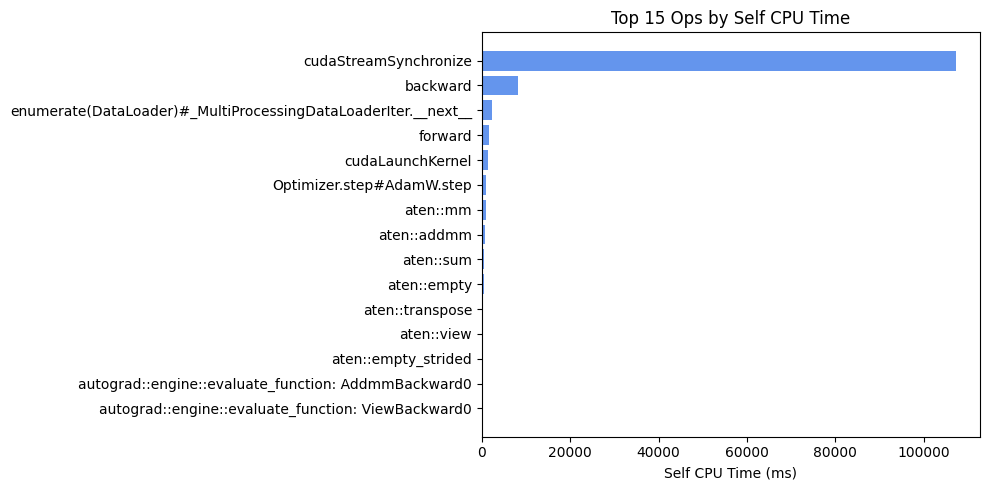

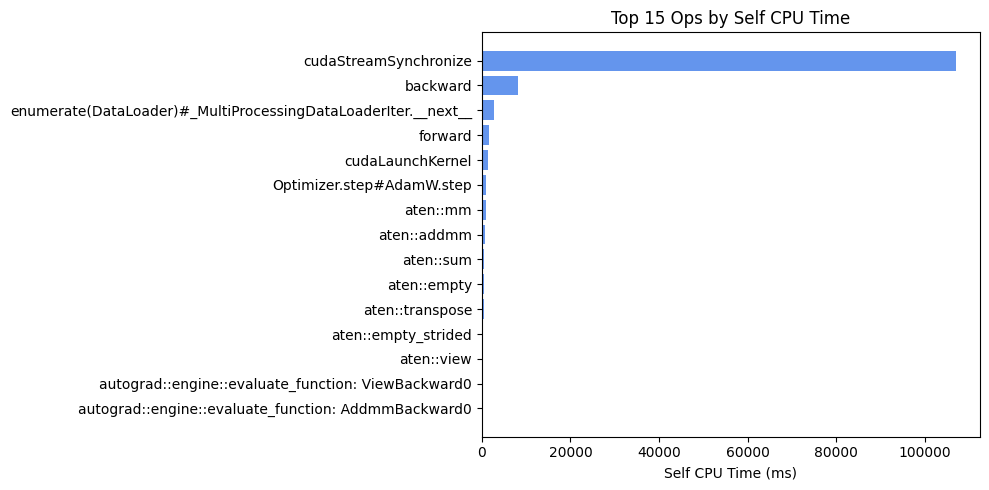

,op,cpu_time_ms
18,cudaStreamSynchronize,107140.581050
84,backward,8272.129919
9,enumerate(DataLoader)#_MultiProcessingDataLoad...,2850.353893
19,forward,1613.066710
27,cudaLaunchKernel,1456.007407
146,Optimizer.step#AdamW.step,1012.785623
97,aten::mm,855.404258
63,aten::addmm,724.385104
98,aten::sum,457.126839
0,aten::empty,456.190004


In [91]:
def plot_top_ops(prof, top_k=15):
    events = prof.key_averages()
    data = []
    for evt in events:
        data.append(
            {
                "op": evt.key,
                "cpu_time_ms": evt.self_cpu_time_total / 1e3,
                # "cuda_time_ms": evt.self_cuda_time_total / 1e3,
            }
        )
    df = pd.DataFrame(data)

    # sort separately
    top_cpu = df.sort_values("cpu_time_ms", ascending=False).head(top_k)
    # top_gpu = df.sort_values("cuda_time_ms", ascending=False).head(top_k)

    # ---- CPU ----
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(top_cpu["op"], top_cpu["cpu_time_ms"], color="cornflowerblue")
    ax.set_xlabel("Self CPU Time (ms)")
    ax.set_title(f"Top {top_k} Ops by Self CPU Time")
    ax.invert_yaxis()

    plt.show()

    # # ---- GPU ----
    # plt.figure(figsize=(10, 5))
    # plt.barh(top_gpu["op"], top_gpu["cuda_time_ms"], color="darkorange")
    # plt.xlabel("Self GPU Time (ms)")
    # plt.title(f"Top {top_k} Ops by Self GPU Time")
    # plt.gca().invert_yaxis()
    # plt.tight_layout()
    # plt.show()

    return top_cpu


plot_top_ops(prof1, top_k=15)
plot_top_ops(prof4, top_k=15)

In [92]:
print(prof1.key_averages().table(sort_by="cpu_time_total", row_limit=10))
print(prof4.key_averages().table(sort_by="cpu_time_total", row_limit=10))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                            aten::copy_         0.06%      72.900ms        81.63%      107.568s      10.581ms      63.510ms         0.05%      63.516ms       6.248us         10166  
                                               aten::to         0.01%      19.217ms        81.62%      107.556s       6.832ms       0.000us         0.00%      31.212ms       1.982us         15744  
         

## C5 CPU vs GPU Training Time Comparison
Train for 5 epochs on CPU and on GPU. Keep batch size and max length fixed across both.


In [133]:
devices = [ 
           "cuda", 
        #    "cpu"
           ]
batch_size = 32
learning_rate = 1e-4
optimum_num_workers = 4
results_c5 = []

for device_name in devices:
    print(device_name)
    current_device = torch.device(device_name)

    wandb_config = {
        "model_name": "distilbert-base-uncased",
        "sequence_length": 256,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "optimizer": "AdamW",
        "number_dataloader_workers": optimum_num_workers,
        "epochs": 5,
        "device": device_name,
        "torch_compile_enabled": False,
        "component": "C5_cpu_vs_gpu",
    }

    run_name = f"device_{device_name}_bs_{batch_size}"
    group_name = "C5_cpu_vs_gpu"
    wandb.init(
        project="hpml-hw2-llm", name=run_name, group=group_name, config=wandb_config
    )

    # recreate DataLoaders
    train_dataloader = DataLoader(
        tokenized_datasets["train"],
        batch_size=batch_size,
        shuffle=True,
        collate_fn=data_collator,
        num_workers=optimum_num_workers,
    )

    # reinitialize model
    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=2
    )
    model = model.to(current_device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    # training metrics storage
    epoch_times = []
    train_losses = []
    train_accuracies = []
    test_accuracies = []

    # training loop
    for epoch in range(EPOCHS):
        print(f"Epoch {epoch + 1}/{EPOCHS} - Device={device_name}")

        model.train()
        total_train_acc = 0
        total_train_loss = 0
        train_batches = 0

        epoch_start_time = time.time()

        for batch in tqdm(train_dataloader, desc=f"Device={device_name}"):
            # Move batch to device
            batch = {k: v.to(current_device) for k, v in batch.items()}

            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # synchronize if using GPU
            if device_name == "cuda":
                torch.cuda.synchronize()

            # metrics
            acc = compute_accuracy(logits, batch["labels"])
            total_train_acc += acc.item()
            total_train_loss += loss.item()
            train_batches += 1

        epoch_end_time = time.time()
        epoch_total_time = epoch_end_time - epoch_start_time

        # calculate averages
        avg_train_loss = total_train_loss / train_batches
        avg_train_acc = total_train_acc / train_batches

        epoch_times.append(epoch_total_time)
        train_losses.append(avg_train_loss)
        train_accuracies.append(avg_train_acc)

        model.eval()
        total_test_acc = 0
        test_batches = 0
        with torch.no_grad():
            for batch in test_dataloader:
                batch = {k: v.to(current_device) for k, v in batch.items()}
                outputs = model(**batch)
                acc = compute_accuracy(outputs.logits, batch["labels"])
                total_test_acc += acc.item()
                test_batches += 1

        test_accuracies.append(total_test_acc / test_batches)

        wandb.log(
            {
                "train/loss": avg_train_loss,
                "train/accuracy": train_accuracies[-1],
                "test/accuracy": test_accuracies[-1],
                "time/epoch_total": epoch_total_time,
                "epoch": epoch + 1,
            }
        )

        print(f"Time: {epoch_total_time:.2f}s")
        print(
            f"Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracies[-1]:.4f}, Test Acc: {test_accuracies[-1]:.4f}"
        )

    # store results
    avg_epoch_time = np.mean(epoch_times)
    final_train_loss = train_losses[-1]
    final_test_acc = test_accuracies[-1]

    results_c5.append(
        {
            "device": device_name.upper(),
            "avg_epoch_time": avg_epoch_time,
            "final_train_loss": final_train_loss,
            "final_test_accuracy": final_test_acc,
        }
    )

    print(f"Device={device_name} Summary:")
    print(f"Avg Epoch Time: {avg_epoch_time:.2f}s")
    print(f"Final Train Loss: {final_train_loss:.4f}")
    print(f"Final Test Accuracy: {final_test_acc:.4f}")
    wandb.finish()

   

socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x153e88b18370>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 153e84c561d0, raw_cell="devices = [ 
           "cuda", 
        #    "cpu.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://tunnel%2Brusty/mnt/home/fgarcia/HPML_autumn25/pset2/hw2_fbg2107.ipynb#Y145sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

cuda


socket.send() raised exception.
socket.send() raised exception.


BrokenPipeError: [Errno 32] Broken pipe

socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x153e88b18370>> (for post_run_cell), with arguments args (<ExecutionResult object at 153e84afd990, execution_count=133 error_before_exec=None error_in_exec=[Errno 32] Broken pipe info=<ExecutionInfo object at 153e84c561d0, raw_cell="devices = [ 
           "cuda", 
        #    "cpu.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://tunnel%2Brusty/mnt/home/fgarcia/HPML_autumn25/pset2/hw2_fbg2107.ipynb#Y145sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

## C6  Hyperparameter Sensitivity

In [94]:
# define the hyperparameter grid
batch_sizes = [16, 32, 64]
learning_rates = [5e-5, 1e-4, 5e-4]

# Results storage
results = []
optimum_num_workers = 4  # From previous experiments
for batch_size in batch_sizes:
    for lr in learning_rates:
        wandb_config = {
            "model_name": "distilbert-base-uncased",
            "sequence_length": 256,
            "batch_size": batch_size,
            "learning_rate": lr,
            "optimizer": "AdamW",
            "number_dataloader_workers": optimum_num_workers,  # Varied parameter
            "epochs": 5,
            "device": "cuda",
            "torch_compile_enabled": False,
            "component": "C6_hyperparameter_tuning",
        }

        run_name = f"bs_{batch_size}_lr_{lr}_workers_{optimum_num_workers}"
        group_name = "C6_hyperparameter_tuning"

        wandb.init(
            project="hpml-hw2-llm", name=run_name, group=group_name, config=wandb_config
        )

        # recreate DataLoaders with current num_workers
        train_dataloader = DataLoader(
            tokenized_datasets["train"],
            batch_size=batch_size,
            shuffle=True,
            collate_fn=data_collator,
            num_workers=optimum_num_workers,  # This is what we're testing
        )

        # reinitialize model and optimizer for fair comparison
        model = DistilBertForSequenceClassification.from_pretrained(
            "distilbert-base-uncased", num_labels=2
        )
        model = model.to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

        # training metrics storage for this run - ADD TRAIN LOSSES
        epoch_times = []
        data_loading_times = []
        compute_times = []
        train_accuracies = []
        train_losses = []
        test_accuracies = []

        # training loop with timing (similar to C2)
        for epoch in range(5):
            print(f"Epoch {epoch + 1}/5 - bs={batch_size}, lr={lr}")

            # Training phase with timing
            model.train()
            epoch_data_loading_time = 0
            epoch_compute_time = 0
            total_train_acc = 0
            total_train_loss = 0
            train_batches = 0

            epoch_start_time = time.time()

            for batch in tqdm(train_dataloader, desc=f"bs={batch_size}, lr={lr}"):
                # data loading time
                data_load_start = time.time()
                batch = {k: v.to(device) for k, v in batch.items()}
                torch.cuda.synchronize()
                data_load_end = time.time()
                epoch_data_loading_time += data_load_end - data_load_start

                # compute time
                compute_start = time.time()
                outputs = model(**batch)
                loss = outputs.loss
                logits = outputs.logits

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                torch.cuda.synchronize()
                compute_end = time.time()
                epoch_compute_time += compute_end - compute_start

                # metrics
                acc = compute_accuracy(logits, batch["labels"])
                total_train_acc += acc.item()
                total_train_loss += loss.item()
                train_batches += 1

            epoch_end_time = time.time()
            epoch_total_time = epoch_end_time - epoch_start_time

            # calculate average training loss for this epoch
            avg_train_loss = total_train_loss / train_batches
            avg_train_acc = total_train_acc / train_batches

            # store metrics
            epoch_times.append(epoch_total_time)
            data_loading_times.append(epoch_data_loading_time)
            compute_times.append(epoch_compute_time)
            train_accuracies.append(avg_train_acc)
            train_losses.append(avg_train_loss)

            # quick test evaluation (no timing)
            model.eval()
            total_test_acc = 0
            test_batches = 0
            with torch.no_grad():
                for batch in test_dataloader:
                    batch = {k: v.to(device) for k, v in batch.items()}
                    outputs = model(**batch)
                    acc = compute_accuracy(outputs.logits, batch["labels"])
                    total_test_acc += acc.item()
                    test_batches += 1

            test_accuracies.append(total_test_acc / test_batches)

            # Log to W&B
            wandb.log(
                {
                    "train/loss": avg_train_loss,
                    "train/accuracy": train_accuracies[-1],
                    "test/accuracy": test_accuracies[-1],
                    "time/data_loading": epoch_data_loading_time,
                    "time/compute": epoch_compute_time,
                    "time/epoch_total": epoch_total_time,
                    "epoch": epoch + 1,
                }
            )

            print(
                f"   Time: Data={epoch_data_loading_time:.2f}s, Compute={epoch_compute_time:.2f}s, Total={epoch_total_time:.2f}s"
            )
            print(
                f"   Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracies[-1]:.4f}, Test Acc: {test_accuracies[-1]:.4f}"  # Updated to show loss
            )

        # store results for this combination
        avg_epoch_time = np.mean(epoch_times)
        avg_data_loading_time = np.mean(data_loading_times)
        avg_compute_time = np.mean(compute_times)
        final_train_loss = train_losses[-1]
        final_train_acc = train_accuracies[-1]
        final_test_acc = test_accuracies[-1]

        results.append(
            {
                "num_workers": optimum_num_workers,
                "batch_size": batch_size,
                "learning_rate": lr,
                "avg_epoch_time": avg_epoch_time,
                "avg_data_loading_time": avg_data_loading_time,
                "avg_compute_time": avg_compute_time,
                "final_train_loss": final_train_loss,
                "final_train_accuracy": final_train_acc,
                "final_test_accuracy": final_test_acc,
            }
        )

        print(f"num_workers={optimum_num_workers} Summary:")
        print(f"avg Epoch Time: {avg_epoch_time:.2f}s")
        print(f"final Train Loss: {final_train_loss:.4f}")
        print(
            f"avg Data Loading: {avg_data_loading_time:.2f}s ({avg_data_loading_time/avg_epoch_time*100:.1f}%)"
        )
        print(f"final Test Accuracy: {final_test_acc:.4f}")

        wandb.finish()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5 - bs=16, lr=5e-05


bs=16, lr=5e-05: 100%|██████████| 1563/1563 [02:16<00:00, 11.43it/s]


   Time: Data=0.26s, Compute=128.24s, Total=136.72s
   Loss: 0.3333, Train Acc: 0.8582, Test Acc: 0.8495
Epoch 2/5 - bs=16, lr=5e-05


bs=16, lr=5e-05: 100%|██████████| 1563/1563 [02:16<00:00, 11.44it/s]


...

bs=64, lr=0.0005: 100%|██████████| 391/391 [02:03<00:00,  3.15it/s]


   Time: Data=0.08s, Compute=118.92s, Total=123.99s
   Loss: 0.0482, Train Acc: 0.9845, Test Acc: 0.8953
Epoch 5/5 - bs=64, lr=0.0005


bs=64, lr=0.0005: 100%|██████████| 391/391 [02:03<00:00,  3.16it/s]


   Time: Data=0.08s, Compute=118.83s, Total=123.66s
   Loss: 0.0345, Train Acc: 0.9883, Test Acc: 0.8904
num_workers=4 Summary:
avg Epoch Time: 123.77s
final Train Loss: 0.0345
avg Data Loading: 0.08s (0.1%)
final Test Accuracy: 0.8904


epoch,▁▃▅▆█
test/accuracy,█▁▆▅▂
time/compute,▁▇▃█▅
time/data_loading,█▆▄▁▅
time/epoch_total,▂▆▁█▂
train/accuracy,▁▅▇██
train/loss,█▄▂▁▁
epoch,5
test/accuracy,0.89043
time/compute,118.833
time/data_loading,0.08212


### Table T6 

Sweep Batch size ∈ {16, 32, 64} and Learning rate ∈ {5 × 10−5 , 10−4 , 5 × 10−4 }.
One row per config, so 9 rows total.

Batch Size | Learning Rate | Avg Epoch Time (s) | Final Train Acc | Train Acc | Test Acc

In [99]:
df_c6 = pd.DataFrame(results)

# reorder columns to match the required table format
df_c6_table = df_c6[
    [
        "batch_size",
        "learning_rate",
        "avg_epoch_time",
        "final_train_loss",
        "final_train_accuracy",
        "final_test_accuracy",
    ]
]

# rename columns to match the assignment requirements
df_c6_table = df_c6_table.rename(
    columns={
        "batch_size": "Batch",
        "learning_rate": "LR",
        "avg_epoch_time": "Avg Epoch Time (s)",
        "final_train_loss": "Final Train Loss",
        "final_train_accuracy": "Train Acc",
        "final_test_accuracy": "Test Acc",
    }
)

# format the values for better readability
df_c6_display = df_c6_table.copy()
df_c6_display["Avg Epoch Time (s)"] = df_c6_display["Avg Epoch Time (s)"].round(2)
df_c6_display["Final Train Loss"] = df_c6_display["Final Train Loss"].round(4)
df_c6_display["Train Acc"] = df_c6_display["Train Acc"].round(4)
df_c6_display["Test Acc"] = df_c6_display["Test Acc"].round(4)
df_c6_display["LR"] = df_c6_display["LR"].apply(
    lambda x: f"{x:.0e}" if x < 0.001 else f"{x:.4f}"
)

# display the table
print("Table T6: Hyperparameter Sensitivity Results")
display(df_c6_display)

# also log as W&B Table
wandb.init(project="hpml-hw2-llm", group="C6_hyperparameter_tuning", name="C6_results")
wandb.log({"C6_Hyperparameter_Results": wandb.Table(dataframe=df_c6_table)})
wandb.finish()

# save df_c6 to txt
df_c6.to_csv("C6_hyperparameter_tuning_results.csv", index=False)

Table T6: Hyperparameter Sensitivity Results


,Batch,LR,Avg Epoch Time (s),Final Train Loss,Train Acc,Test Acc
0,16,5e-05,136.43,0.4303,0.7283,0.5003
1,16,1e-04,136.33,0.1157,0.9596,0.8222
2,16,5e-04,136.43,0.6932,0.4967,0.5005
3,32,5e-05,131.05,0.0383,0.9879,0.8691
4,32,1e-04,131.10,0.0434,0.9852,0.8594
5,32,5e-04,131.05,0.0365,0.9885,0.8698
6,64,5e-05,123.74,0.0296,0.9894,0.8839
7,64,1e-04,123.77,0.0377,0.9877,0.8883
8,64,5e-04,123.77,0.0345,0.9883,0.8904


### Figure F6a and F6b

Here we show the heat map for each of the two metrics (avg epoch time on the left and test accuracy on the right) as a function of batch size and learning rate.

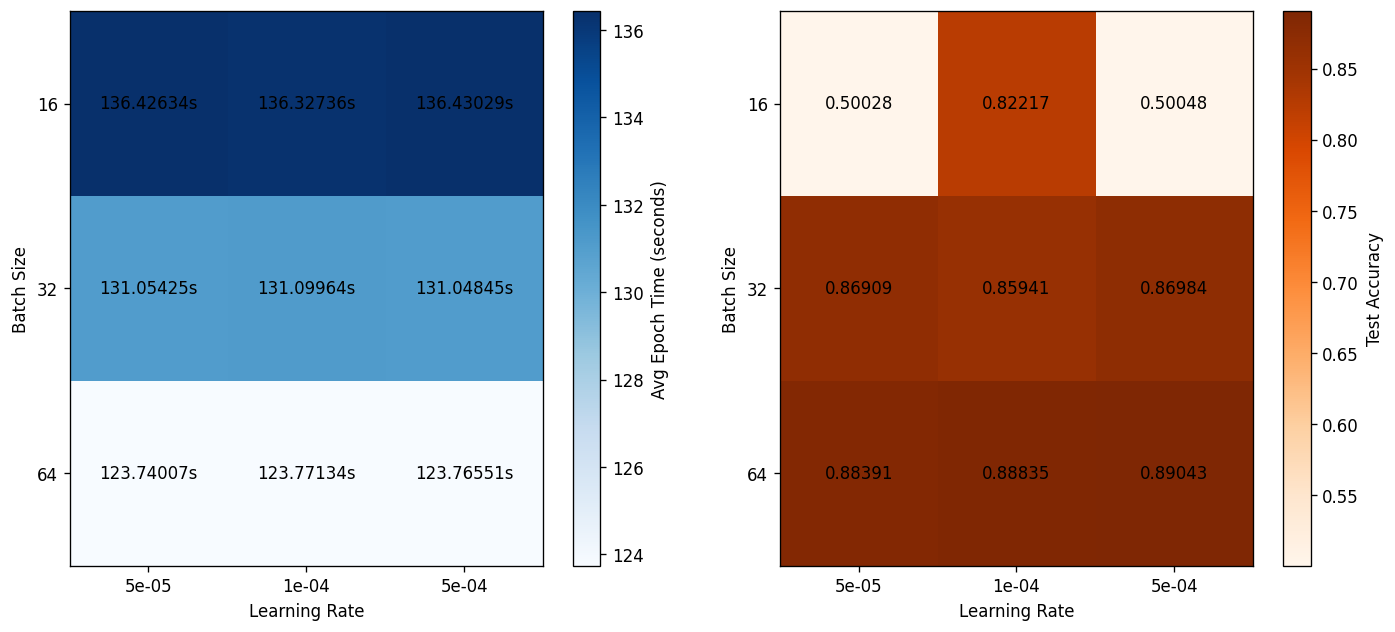

In [110]:
# Create the figure with 2 subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6), dpi=120)

# Prepare data for heatmaps - pivot the data
heatmap_time = df_c6_table.pivot(
    index="Batch", columns="LR", values="Avg Epoch Time (s)"
)
heatmap_accuracy = df_c6_table.pivot(index="Batch", columns="LR", values="Test Acc")

# Figure F6a: Heatmap of avg epoch time
im1 = ax[0].imshow(heatmap_time.values, cmap="Blues", aspect="auto")

ax[0].set(xlabel="Learning Rate", ylabel="Batch Size")
ax[0].set_xticks(range(len(heatmap_time.columns)))
ax[0].set_xticklabels([f"{lr:.0e}" for lr in heatmap_time.columns])
ax[0].set_yticks(range(len(heatmap_time.index)))
ax[0].set_yticklabels(heatmap_time.index)

for i in range(len(heatmap_time.index)):
    for j in range(len(heatmap_time.columns)):
        ax[0].text(
            j,
            i,
            f"{heatmap_time.values[i, j]:.5f}s",
            ha="center",
            va="center",
            color="k",
        )

plt.colorbar(im1, ax=ax[0], label="Avg Epoch Time (seconds)")

# Figure F6b
im2 = ax[1].imshow(heatmap_accuracy.values, cmap="Oranges", aspect="auto")

ax[1].set(xlabel="Learning Rate", ylabel="Batch Size")
ax[1].set_xticks(range(len(heatmap_accuracy.columns)))
ax[1].set_xticklabels([f"{lr:.0e}" for lr in heatmap_accuracy.columns])
ax[1].set_yticks(range(len(heatmap_accuracy.index)))
ax[1].set_yticklabels(heatmap_accuracy.index)

for i in range(len(heatmap_accuracy.index)):
    for j in range(len(heatmap_accuracy.columns)):
        ax[1].text(
            j,
            i,
            f"{heatmap_accuracy.values[i, j]:.5f}",
            ha="center",
            va="center",
            color="k",
        )
plt.colorbar(im2, ax=ax[1], label="Test Accuracy")
plt.show()
fig.savefig("F6_hyperparameter_heatmaps.png", dpi=300, bbox_inches="tight")


# wandb.init(project="hpml-hw2-llm", group="C6_figures")
# wandb.log({"F6_Hyperparameter_Heatmaps": wandb.Image(fig)})
# wandb.finish()

### Discussion of Results

In Figure F6a, we observe the average epoch time as a function of batch size (y axis) and learning rate (x axis). The heatmap indicates that larger batch sizes tend to results in faster avg epoch time, which makes sense given the reduced number of weight updates per epoch. Across learning rates, the average epoch time appears to be relatively stable, with only minor fluctuations.

In Figure F6b, we examine the test accuracy under the same conditions. We observe that higher batch sizes tend to achive better test accuracy in the case between the 32 and 64 batch size comparison. Which is likely due to the fact that larger batch sizes provide a more stable estimate of the gradient, leading to better convergence during training.  However, for smaller batches (16), the 1e-4 learning rate is the most optimal (achieveing the lowest test accuracy however)-- this suggests that smaller batch sizes tend to be not as stables and require careful tuning of the learning rate to achieve decent performance.


## C7 Optimizer Comparison

Train for 5 epochs with SGD, Adam, and AdamW (same batch size/lr unless optimizer
requires adjustment).

In [111]:
optimizers = ["SGD", "Adam", "AdamW"]
learning_rate = 1e-4  # fixed  to what we been using
batch_size = 32  # what we been using
optimum_num_workers = 4  # from previous experiments, this was the best from C3

# Results storage
results_c7 = []

for optimizer_name in optimizers:
    wandb_config = {
        "model_name": "distilbert-base-uncased",
        "sequence_length": 256,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "optimizer": optimizer_name,
        "number_dataloader_workers": optimum_num_workers,
        "epochs": 5,
        "device": "cuda",
        "torch_compile_enabled": False,
        "component": "C7_optimizer_comparison",
    }

    run_name = f"optimizer_{optimizer_name}_bs_{batch_size}_lr_{learning_rate}"
    group_name = "C7_optimizer_comparison"

    wandb.init(
        project="hpml-hw2-llm", name=run_name, group=group_name, config=wandb_config
    )

    # recreate DataLoaders
    train_dataloader = DataLoader(
        tokenized_datasets["train"],
        batch_size=batch_size,
        shuffle=True,
        collate_fn=data_collator,
        num_workers=optimum_num_workers,
    )

    # reinitialize model for fair comparison
    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=2
    )
    model = model.to(device)

    # initialize appropriate optimizer
    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    # training metrics storage for this run
    epoch_times = []
    data_loading_times = []
    compute_times = []
    train_accuracies = []
    train_losses = []
    test_accuracies = []

    # training loop with timing
    for epoch in range(EPOCHS):
        print(f"Epoch {epoch + 1}/{EPOCHS} - Optimizer={optimizer_name}")

        # training phase with timing
        model.train()
        epoch_data_loading_time = 0
        epoch_compute_time = 0
        total_train_acc = 0
        total_train_loss = 0
        train_batches = 0

        epoch_start_time = time.time()

        for batch in tqdm(train_dataloader, desc=f"Optimizer={optimizer_name}"):
            # data loading time
            data_load_start = time.time()
            batch = {k: v.to(device) for k, v in batch.items()}
            torch.cuda.synchronize()
            data_load_end = time.time()
            epoch_data_loading_time += data_load_end - data_load_start

            # compute time
            compute_start = time.time()
            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            torch.cuda.synchronize()
            compute_end = time.time()
            epoch_compute_time += compute_end - compute_start

            # metrics
            acc = compute_accuracy(logits, batch["labels"])
            total_train_acc += acc.item()
            total_train_loss += loss.item()
            train_batches += 1

        epoch_end_time = time.time()
        epoch_total_time = epoch_end_time - epoch_start_time

        # calculate average training loss for this epoch
        avg_train_loss = total_train_loss / train_batches
        avg_train_acc = total_train_acc / train_batches

        # store metrics
        epoch_times.append(epoch_total_time)
        data_loading_times.append(epoch_data_loading_time)
        compute_times.append(epoch_compute_time)
        train_accuracies.append(avg_train_acc)
        train_losses.append(avg_train_loss)

        # test evaluation
        model.eval()
        total_test_acc = 0
        test_batches = 0
        with torch.no_grad():
            for batch in test_dataloader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                acc = compute_accuracy(outputs.logits, batch["labels"])
                total_test_acc += acc.item()
                test_batches += 1

        test_accuracies.append(total_test_acc / test_batches)

        # Log to W&B
        wandb.log(
            {
                "train/loss": avg_train_loss,
                "train/accuracy": train_accuracies[-1],
                "test/accuracy": test_accuracies[-1],
                "time/data_loading": epoch_data_loading_time,
                "time/compute": epoch_compute_time,
                "time/epoch_total": epoch_total_time,
                "epoch": epoch + 1,
            }
        )

        print(
            f"   Time: Data={epoch_data_loading_time:.2f}s, Compute={epoch_compute_time:.2f}s, Total={epoch_total_time:.2f}s"
        )
        print(
            f"   Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracies[-1]:.4f}, Test Acc: {test_accuracies[-1]:.4f}"
        )

    # store results for this optimizer
    avg_epoch_time = np.mean(epoch_times)
    final_train_loss = train_losses[-1]
    final_train_acc = train_accuracies[-1]
    final_test_acc = test_accuracies[-1]

    results_c7.append(
        {
            "optimizer": optimizer_name,
            "avg_epoch_time": avg_epoch_time,
            "final_train_loss": final_train_loss,
            "final_train_accuracy": final_train_acc,
            "final_test_accuracy": final_test_acc,
        }
    )

    print(f"Optimizer={optimizer_name} Summary:")
    print(f"Avg Epoch Time: {avg_epoch_time:.2f}s")
    print(f"Final Train Loss: {final_train_loss:.4f}")
    print(f"Final Train Accuracy: {final_train_acc:.4f}")
    print(f"Final Test Accuracy: {final_test_acc:.4f}")

    wandb.finish()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5 - Optimizer=SGD


Optimizer=SGD: 100%|██████████| 782/782 [02:07<00:00,  6.12it/s]


   Time: Data=0.13s, Compute=122.28s, Total=127.88s
   Loss: 0.6903, Train Acc: 0.5265, Test Acc: 0.6192
Epoch 2/5 - Optimizer=SGD


Optimizer=SGD: 100%|██████████| 782/782 [02:08<00:00,  6.10it/s]


...

Optimizer=AdamW: 100%|██████████| 782/782 [02:10<00:00,  5.99it/s]


   Time: Data=0.12s, Compute=124.58s, Total=130.53s
   Loss: 0.0566, Train Acc: 0.9809, Test Acc: 0.8756
Epoch 5/5 - Optimizer=AdamW


Optimizer=AdamW: 100%|██████████| 782/782 [02:10<00:00,  5.99it/s]


   Time: Data=0.13s, Compute=124.65s, Total=130.57s
   Loss: 0.0398, Train Acc: 0.9864, Test Acc: 0.8724
Optimizer=AdamW Summary:
Avg Epoch Time: 130.58s
Final Train Loss: 0.0398
Final Train Accuracy: 0.9864
Final Test Accuracy: 0.8724


epoch,▁▃▅▆█
test/accuracy,█▂▂▂▁
time/compute,▄▅█▁▅
time/data_loading,█▇▁▁▇
time/epoch_total,█▂▁▂▃
train/accuracy,▁▅▇██
train/loss,█▄▂▁▁
epoch,5
test/accuracy,0.87244
time/compute,124.64756
time/data_loading,0.13346


### Table T7 


In [112]:
df_c7 = pd.DataFrame(results_c7)

# reorder
df_c7_table = df_c7[
    [
        "optimizer",
        "avg_epoch_time",
        "final_train_loss",
        "final_train_accuracy",
        "final_test_accuracy",
    ]
]

# rename columns
df_c7_table = df_c7_table.rename(
    columns={
        "optimizer": "Optimizer",
        "avg_epoch_time": "Avg Epoch Time (s)",
        "final_train_loss": "Final Train Loss",
        "final_train_accuracy": "Train Acc",
        "final_test_accuracy": "Test Acc",
    }
)

# format values
df_c7_display = df_c7_table.copy()
df_c7_display["Avg Epoch Time (s)"] = df_c7_display["Avg Epoch Time (s)"].round(4)
df_c7_display["Final Train Loss"] = df_c7_display["Final Train Loss"].round(6)
df_c7_display["Train Acc"] = df_c7_display["Train Acc"].round(6)
df_c7_display["Test Acc"] = df_c7_display["Test Acc"].round(6)

display(df_c7_display)

# save to csv
df_c7.to_csv("C7_optimizer_comparison_results.csv", index=False)

,Optimizer,Avg Epoch Time (s),Final Train Loss,Train Acc,Test Acc
0,SGD,128.1548,0.654424,0.731458,0.809143
1,Adam,130.1942,0.039453,0.986493,0.878277
2,AdamW,130.5800,0.039841,0.986413,0.872442


### Figure F7 Bar Chart

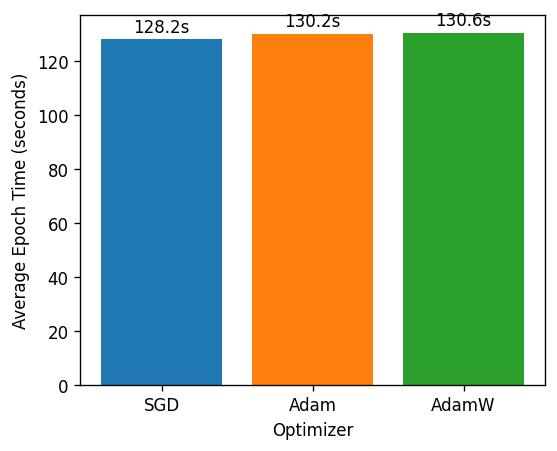

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=120)
bars = ax.bar(
    df_c7_table["Optimizer"],
    df_c7_table["Avg Epoch Time (s)"],
    color=["tab:blue", "tab:orange", "tab:green"],
)


ax.set(ylabel="Average Epoch Time (seconds)", xlabel="Optimizer")

# add values on top of bars
for i, v in enumerate(df_c7_table["Avg Epoch Time (s)"]):
    ax.text(
        i,
        v + max(df_c7_table["Avg Epoch Time (s)"]) * 0.01,
        f"{v:.1f}s",
        ha="center",
        va="bottom",
    )

plt.show()
plt.savefig("F7_optimizer_times.png", dpi=300, bbox_inches="tight")

wandb.init(project="hpml-hw2-llm", group="C7_figures", name="C7_F7_optimizer_times")
wandb.log({"F7_Optimizer_Times": wandb.Image(fig)})
wandb.finish()

![F7_optimizer_times  ](F7_convergence_variance.png)

### Convergence and Variance Observations




We see from above that SGD is the faster on average per epoch, followed by Adam and AdamW being the slowest. However, by looking at the convergence above, the test accurayc for SGD is significantly lower than both Adam and AdamW. Furthermore, it seems like SGD is slower to converge (to a lower accuracy), which makes sense given what we learned about it in lecture. 

## C8 torch compile